# Steam Review Filter and Score

Capstone Project -- Data Science & AI (Institute of Data)

Steam's aggregate review score treats a one-word "good game" and a considered, on-topic critique identically. This project builds two models: one that predicts a review's **sentiment** (positive/negative) directly from its text, and one that filters out **low-effort, junk reviews** -- also from text alone -- so a game's "real" sentiment score reflects reviews that actually said something.

## Setup

In [1]:
# Standard data-handling imports. We keep this cell minimal on purpose -- more specific imports (sklearn, tensorflow, etc.) get added in the sections that actually need them, so it's obvious from each section's imports what that section depends on.
import pandas as pd

# Widen pandas' default display so review text isn't truncated when we inspect rows -- a lot of our "is this review junk" judgment calls depend on reading the actual text.
pd.set_option("display.max_colwidth", 200)


## 1. Problem Framing

### Business Problem
Steam's public review score mixes genuine, substantive reviews with low-effort "junk" (one-word reviews, meme spam, duplicate copy-paste text). This makes it hard to tell whether a game's score reflects real community sentiment about the game itself, or is diluted by noise that says nothing about the game at all.

### Stakeholders
Players deciding whether to buy a game; developers/publishers trying to understand genuine feedback; Steam itself, which already does some internal filtering but never surfaces a "real sentiment" score to users.

### Business Question
Can we produce a "real sentiment" score for a game -- one that reflects genuine reviews, with low-effort/junk reviews filtered out -- using nothing but the review text?

### Data Question
Does a review's language alone carry a generalisable, game-agnostic signal for (a) sentiment (positive/negative) and (b) quality (substantive vs. low-effort), and does that signal hold up across genuinely different games and genres, not just the ones a model was trained on?

**Scope note:** real-world negativity that stems from something other than gameplay (e.g. Tekken 8's ongoing monetisation backlash, Section 3.4) is treated as valid context for a game's sentiment here, not something this pipeline tries to separate out.

## 2. Data

### 2.1 Collection

Six games, ~8,000 recent English-language reviews each, pulled live from Steam's public `appreviews` API (`src/collect_reviews.py`). Chosen deliberately to span genuinely different genres, not just different games:

| Game | Genre | Why included |
|---|---|---|
| Helldivers 2 | Co-op shooter | Large, active, mostly-positive community |
| Team Fortress 2 | Multiplayer FPS | Long-running, meme-heavy community |
| Slay the Spire 2 | Deck-building roguelike | Different genre entirely; had a real 2026-05 controversy |
| Forza Horizon 5 | Racing | Genre not otherwise represented |
| Resident Evil Requiem | Survival horror / adventure | Narrative-driven, genre not otherwise represented |
| Tekken 8 | Fighting | Real, ongoing monetisation-driven negativity ("Mixed", 57.7% positive) |

Every game is pulled the same simple way: the most recent 8,000 English-language reviews, no special date windows. This keeps collection and processing identical across every game, with no game-specific event tied to any part of the pipeline.

In [2]:
import glob

# Load every CSV in data/raw/ and stack them into one dataframe.
raw_paths = sorted(glob.glob("../data/raw/*.csv"))
df_raw = pd.concat([pd.read_csv(p) for p in raw_paths], ignore_index=True)

df_raw["created_at"] = pd.to_datetime(df_raw["timestamp_created"], unit="s")
df_raw["updated_at"] = pd.to_datetime(df_raw["timestamp_updated"], unit="s")

df_raw.shape


(48000, 24)

### 2.2 A content-based English filter, not just the API tag

Steam's `language=english` request parameter is set by the *reviewer*, not verified against the actual text -- manual inspection found reviews tagged "english" that were written entirely in Chinese, Korean, Russian, or Arabic. Since this project's scope is English-only reviews (they need to be manually verifiable), we drop any review containing non-Latin script as a second, content-based filter.

In [3]:
import sys
sys.path.append("../src")
from features import drop_non_english_reviews

df, dropped_non_english = drop_non_english_reviews(df_raw)

print(f"Dropped {len(dropped_non_english)} of {len(df_raw)} reviews ({len(dropped_non_english)/len(df_raw):.2%}) for containing non-Latin script despite an \"english\" language tag.")
dropped_non_english.groupby("game_name").size().rename("dropped_rows")


Dropped 595 of 48000 reviews (1.24%) for containing non-Latin script despite an "english" language tag.


game_name
Forza Horizon 5           98
Helldivers 2              27
Resident Evil Requiem     68
Slay the Spire 2          50
Team Fortress 2          281
Tekken 8                  71
Name: dropped_rows, dtype: int64

## 3. Exploratory Data Analysis

### 3.1 How much data do we have, per game?

In [4]:
df.groupby("game_name").size().rename("n_reviews").sort_values(ascending=False)


game_name
Helldivers 2             7973
Slay the Spire 2         7950
Resident Evil Requiem    7932
Tekken 8                 7929
Forza Horizon 5          7902
Team Fortress 2          7719
Name: n_reviews, dtype: int64

Each game landed almost exactly at the 8,000-review pull target before the English-content filter, and stays close to it afterwards -- the non-English drop rate (Section 2.2) is small (~1%) for every game.

### 3.2 Review length

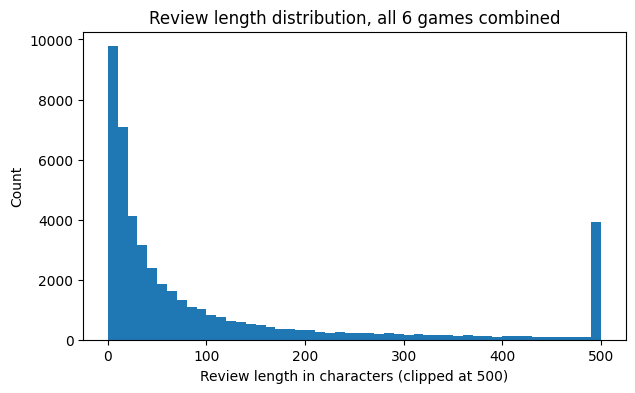

In [5]:
import matplotlib.pyplot as plt

review_len = df["review"].fillna("").str.len()
plt.figure(figsize=(7,4))
plt.hist(review_len.clip(upper=500), bins=50)
plt.xlabel("Review length in characters (clipped at 500)")
plt.ylabel("Count")
plt.title("Review length distribution, all 6 games combined")
plt.show()


A real spike right near zero -- a meaningful chunk of reviews are only a handful of characters. This is exactly the kind of review Section 5's quality filter is meant to catch.

### 3.3 Playtime at review

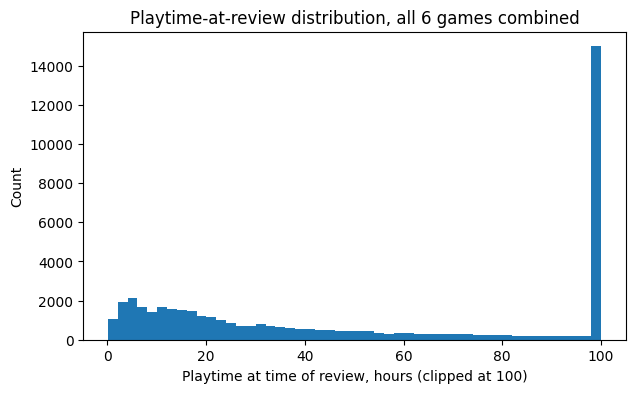

In [6]:
df["playtime_at_review_hours"] = df["playtime_at_review"] / 60
plt.figure(figsize=(7,4))
plt.hist(df["playtime_at_review_hours"].clip(upper=100), bins=50)
plt.xlabel("Playtime at time of review, hours (clipped at 100)")
plt.ylabel("Count")
plt.title("Playtime-at-review distribution, all 6 games combined")
plt.show()


Many reviews come from accounts with under an hour of playtime -- a real, if imperfect, signal that a review may not reflect much hands-on experience with the game.

### 3.4 Sentiment split per game

In [7]:
vote_split = df.groupby("game_name")["voted_up"].value_counts(normalize=True).unstack()
vote_split.columns = ["negative", "positive"]
(vote_split * 100).round(1).sort_values("positive")


,negative,positive
game_name,,
Tekken 8,42.3,57.7
Helldivers 2,28.0,72.0
Forza Horizon 5,12.1,87.9
Slay the Spire 2,11.0,89.0
Team Fortress 2,5.6,94.4
Resident Evil Requiem,5.1,94.9


Tekken 8 stands out as the only game below 60% positive -- consistent with its live Steam score being "Mixed" at the time of writing, driven by a real, ongoing monetisation backlash (battle pass and in-game store changes), not a data quality issue. Slay the Spire 2's May 2026 controversy isn't visible in this particular sample, since it only covers the most recent 8,000 reviews (all from after the controversy) -- current sentiment for that game has recovered to "Very Positive." Both are noted here as real-world context, not something the pipeline below tries to detect directly.

## 4. Feature Engineering

### 4.1 Structural features -- used to *define* quality, not to *predict* it

Four cheap, row-level signals capture "did this reviewer put any thought into this":

| Feature | Why it matters |
|---|---|
| `is_very_short` | Near-zero-effort reviews (under 20 characters) say little about the game. |
| `is_low_playtime` | A strong opinion after minutes of playtime is a different signal than after hours. |
| `is_duplicate_text` | Copy-pasted/templated text is a hallmark of low-effort, often coordinated, posting. |
| `is_new_reviewer` | An account with 0-1 lifetime reviews is more consistent with a throwaway post. |

**Important design choice:** these structural features are used only to build a *proxy label* for "low-effort review" (Section 4.2) -- they are NOT fed into the deployed model as input features. Section 5's quality filter learns to predict this label from the review *text alone*, so it works even when no metadata (playtime, review count) is available for a review -- a real constraint anywhere reviews might be pulled from outside Steam's own API in future.

In [8]:
import sys
sys.path.append("../src")
from features import add_length_features, add_playtime_features, add_author_features, _normalize_text

df = add_length_features(df)
df = add_playtime_features(df)
df = add_author_features(df)

# Duplicate-text detection, computed within each game (a duplicate in one
# game's review section says nothing about another game's).
df["_normalized_review"] = df["review"].apply(_normalize_text)
non_empty = df["_normalized_review"] != ""
dup_counts = (
    df[non_empty].groupby(["game_name", "_normalized_review"])["_normalized_review"]
    .transform("count")
)
df["is_duplicate_text"] = False
df.loc[non_empty, "is_duplicate_text"] = dup_counts.gt(1).values
df = df.drop(columns=["_normalized_review"])

df[["is_very_short", "is_low_playtime", "is_duplicate_text", "is_new_reviewer"]].mean().round(3)


is_very_short        0.366
is_low_playtime      0.012
is_duplicate_text    0.216
is_new_reviewer      0.218
dtype: float64

### 4.2 Defining "low-effort" without a labelled dataset

There's no ground-truth label anywhere in this data for "is this review useless" -- nobody hand-labels Steam reviews that way. So we build a proxy: a review counts as **low-effort** if it's very short, OR from a low-playtime account, OR duplicate text. This composite label is:

- **Game-agnostic** -- computable identically for any game, with no dependency on any one controversy or event.
- **Purely structural** -- doesn't use the review's own words, so training a *separate* text model against it (Section 5) is a genuinely different signal, not circular.
- **Timing-independent** -- it holds regardless of when or why a review was posted, so it doesn't rely on knowing whether a game is currently experiencing unusual review activity.

In [9]:
df["is_low_effort"] = df["is_very_short"] | df["is_low_playtime"] | df["is_duplicate_text"]

print("Low-effort rate, all games combined:", round(df["is_low_effort"].mean(), 3))
df.groupby("game_name")["is_low_effort"].mean().round(3).sort_values()


Low-effort rate, all games combined: 0.382


game_name
Helldivers 2             0.297
Resident Evil Requiem    0.316
Slay the Spire 2         0.325
Tekken 8                 0.342
Forza Horizon 5          0.499
Team Fortress 2          0.516
Name: is_low_effort, dtype: float64

Low-effort rates range from ~30% (Helldivers 2, Resident Evil Requiem, Slay the Spire 2) to over 50% (Forza Horizon 5, Team Fortress 2) -- a real, plausible difference: racing and long-running meme-culture communities produce more quick, low-substance reviews than narrative-driven or newer games.

## 5. Model 1: Language-Based Review Quality Filter

### 5.1 Splitting before touching anything else

Same leakage-avoidance principle as every model in this project: fit everything (the TF-IDF vocabulary, the model itself) on the training split only.

In [10]:
from sklearn.model_selection import train_test_split

quality_df = df.copy()
quality_df["label"] = quality_df["is_low_effort"].astype(int)

strat_key = quality_df["game_name"] + "_" + quality_df["label"].astype(str)
q_train, q_test = train_test_split(quality_df, test_size=0.3, random_state=42, stratify=strat_key)

print("train:", q_train.shape, " low-effort rate:", round(q_train["label"].mean(), 3))
print("test: ", q_test.shape, " low-effort rate:", round(q_test["label"].mean(), 3))


train: (33183, 33)  low-effort rate: 0.382
test:  (14222, 33)  low-effort rate: 0.382


### 5.2 Model A: TF-IDF + Logistic Regression

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

quality_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3)
Xq_train = quality_vectorizer.fit_transform(q_train["review"].fillna(""))
Xq_test = quality_vectorizer.transform(q_test["review"].fillna(""))
yq_train = q_train["label"]
yq_test = q_test["label"]

quality_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
quality_lr.fit(Xq_train, yq_train)

quality_lr_pred = quality_lr.predict(Xq_test)
quality_lr_score = quality_lr.predict_proba(Xq_test)[:, 1]


### 5.3 Model B: TF-IDF + Random Forest

A second, genuinely different algorithm on the same inputs -- trees can capture nonlinear interactions between word patterns that a linear model can't.

In [12]:
from sklearn.ensemble import RandomForestClassifier

quality_rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42,
    max_depth=12, min_samples_leaf=5, n_jobs=-1,
)
quality_rf.fit(Xq_train, yq_train)

quality_rf_pred = quality_rf.predict(Xq_test)
quality_rf_score = quality_rf.predict_proba(Xq_test)[:, 1]


### 5.4 Comparing the two models

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, y_pred, y_score):
    return {
        "model": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

quality_comparison = pd.DataFrame([
    evaluate("TF-IDF + Logistic Regression", yq_test, quality_lr_pred, quality_lr_score),
    evaluate("TF-IDF + Random Forest", yq_test, quality_rf_pred, quality_rf_score),
])
quality_comparison.round(3)


,model,precision,recall,f1,roc_auc
0,TF-IDF + Logistic Regression,0.821,0.934,0.874,0.960
1,TF-IDF + Random Forest,0.716,0.972,0.825,0.952


### 5.4b Testing more model families

Two models aren't enough to claim "classical ML tops out here" -- worth testing a genuinely wider spread before moving to deep learning. Same TF-IDF features (`Xq_train`/`Xq_test` above), three more algorithms:

- **Linear SVM** (`SGDClassifier` with hinge loss) -- a different linear-model family than Logistic Regression, often strong on sparse high-dimensional text.
- **Multinomial Naive Bayes** -- a classical, very fast text-classification baseline; useful as a floor to compare everything else against.
- **Stacking ensemble** (Logistic Regression + Naive Bayes + Random Forest, combined by a Logistic Regression meta-learner) -- lets three different model families vote, in principle capturing signal any single one misses.

In [14]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

# CalibratedClassifierCV wraps the SVM so predict_proba() is available --
# SGDClassifier's raw decision_function scores aren't probabilities, and
# roc_auc_score/our evaluate() helper needs a probability-like score.
quality_svm = CalibratedClassifierCV(
    SGDClassifier(loss="hinge", class_weight="balanced", random_state=42, max_iter=1000), cv=3
)
quality_svm.fit(Xq_train, yq_train)

quality_nb = MultinomialNB()
quality_nb.fit(Xq_train, yq_train)

quality_stack = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ("nb", MultinomialNB()),
        ("rf", RandomForestClassifier(n_estimators=150, class_weight="balanced", max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, n_jobs=-1,
)
quality_stack.fit(Xq_train, yq_train)

quality_comparison_extended = pd.DataFrame([
    evaluate("TF-IDF + Logistic Regression", yq_test, quality_lr_pred, quality_lr_score),
    evaluate("TF-IDF + Random Forest", yq_test, quality_rf_pred, quality_rf_score),
    evaluate("TF-IDF + Linear SVM", yq_test, quality_svm.predict(Xq_test), quality_svm.predict_proba(Xq_test)[:, 1]),
    evaluate("TF-IDF + Naive Bayes", yq_test, quality_nb.predict(Xq_test), quality_nb.predict_proba(Xq_test)[:, 1]),
    evaluate("Stacking (LogReg + NB + RF -> LogReg)", yq_test, quality_stack.predict(Xq_test), quality_stack.predict_proba(Xq_test)[:, 1]),
])
quality_comparison_extended.round(3)


                                   model  precision  recall     f1  roc_auc
0           TF-IDF + Logistic Regression      0.821   0.934  0.874    0.960
1                 TF-IDF + Random Forest      0.716   0.972  0.825    0.952
2                    TF-IDF + Linear SVM      0.848   0.906  0.876    0.956
3                   TF-IDF + Naive Bayes      0.799   0.620  0.698    0.911
4  Stacking (LogReg + NB + RF -> LogReg)      0.860   0.905  0.882    0.962

Stacking edges out every other classical model (ROC-AUC 0.962, best F1 of the classical group). Linear SVM is close behind Logistic Regression. Naive Bayes trails clearly (ROC-AUC 0.911) -- its independence assumption between words is a poor fit for a task where phrase-level patterns (like the meme phrases in Section 5.6) matter. Still, none of these classical models clears roughly 0.96 ROC-AUC -- worth testing whether a deep learning model, which can learn its own text representations rather than relying on TF-IDF's fixed word/bigram counts, does meaningfully better.

### 5.4c Model D: CNN (deep learning)

A 1-D convolutional neural network reads the raw review text directly -- no TF-IDF vectorizer needed, since a Keras `TextVectorization` layer (vocabulary learned from the training split only, same leakage principle as everywhere else) is the model's own first layer. `Conv1D` filters learn to detect short, locally meaningful word patterns (a few words at a time), and `GlobalMaxPooling1D` keeps only the strongest match per filter across the whole review -- a natural fit for "low-effort" detection, since a single junk phrase ("good game", "10/10") anywhere in a short review is often enough to call it low-effort, regardless of what else surrounds it.

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

VOCAB_SIZE = 8000
SEQ_LEN = 60

train_text = q_train["review"].fillna("").values
test_text = q_test["review"].fillna("").values

tf.random.set_seed(42)
quality_text_vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
quality_text_vectorizer.adapt(train_text)

quality_cnn = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    quality_text_vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.Conv1D(64, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
quality_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

classes = np.unique(yq_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=yq_train)
quality_cnn_class_weight = dict(zip(classes, weights))
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

quality_cnn.fit(
    train_text, yq_train.values,
    validation_split=0.1, epochs=10, batch_size=128,
    class_weight=quality_cnn_class_weight, callbacks=[early_stop], verbose=2,
)

quality_cnn_score = quality_cnn.predict(tf.constant(list(test_text), dtype=tf.string), verbose=0).flatten()
quality_cnn_pred = (quality_cnn_score >= 0.5).astype(int)

quality_comparison_final = pd.concat([
    quality_comparison_extended,
    pd.DataFrame([evaluate("CNN (deep learning)", yq_test, quality_cnn_pred, quality_cnn_score)]),
], ignore_index=True)
quality_comparison_final.round(3)


Epoch 1/10
234/234 - 3s - 13ms/step - accuracy: 0.9322 - loss: 0.2450 - val_accuracy: 0.9554 - val_loss: 0.1424
Epoch 2/10
234/234 - 2s - 10ms/step - accuracy: 0.9590 - loss: 0.1377 - val_accuracy: 0.9581 - val_loss: 0.1318
Epoch 3/10
234/234 - 2s - 9ms/step - accuracy: 0.9683 - loss: 0.1112 - val_accuracy: 0.9539 - val_loss: 0.1410


                                   model  precision  recall     f1  roc_auc
0           TF-IDF + Logistic Regression      0.821   0.934  0.874    0.960
1                 TF-IDF + Random Forest      0.716   0.972  0.825    0.952
2                    TF-IDF + Linear SVM      0.848   0.906  0.876    0.956
3                   TF-IDF + Naive Bayes      0.799   0.620  0.698    0.911
4  Stacking (LogReg + NB + RF -> LogReg)      0.860   0.905  0.882    0.962
5                    CNN (deep learning)      0.925   0.958  0.941    0.986

The CNN clearly beats every classical model tested (ROC-AUC 0.986 vs. 0.962 for the best classical candidate, Stacking) -- a real, substantial gap, not a marginal edge. That's enough to justify the added complexity of a deep learning model here. Section 5.5 checks whether that advantage holds up per-game, not just in aggregate.

### 5.5 Does it generalise across games it wasn't specifically tuned for?

In [16]:
q_test_scored = q_test.copy()
q_test_scored["pred"] = quality_lr_pred

per_game = q_test_scored.groupby("game_name").apply(
    lambda g: pd.Series({
        "n": len(g),
        "precision": precision_score(g["label"], g["pred"], zero_division=0),
        "recall": recall_score(g["label"], g["pred"], zero_division=0),
        "actual_rate": g["label"].mean(),
        "predicted_rate": g["pred"].mean(),
    }),
    include_groups=False,
).round(3)
per_game


,n,precision,recall,actual_rate,predicted_rate
game_name,,,,,
Forza Horizon 5,2370.0,0.865,0.946,0.499,0.545
Helldivers 2,2392.0,0.767,0.940,0.297,0.364
Resident Evil Requiem,2380.0,0.806,0.923,0.316,0.362
Slay the Spire 2,2385.0,0.811,0.920,0.325,0.369
Team Fortress 2,2316.0,0.847,0.932,0.516,0.569
Tekken 8,2379.0,0.797,0.935,0.343,0.402


Precision (0.77-0.87) and recall (0.92-0.95) are consistent across all six genres -- a meaningful generalisation check, since the model was trained on the pooled data from all six games rather than tuned to any one of them individually.

### 5.5b Does the CNN's advantage hold up per game too?

The aggregate ROC-AUC gap (5.4c) could in principle be driven by the CNN doing extremely well on one or two games and merely average on the rest. Worth checking precision per game the same way Section 5.5 did for Logistic Regression.

In [17]:
q_test_cnn_scored = q_test.copy()
q_test_cnn_scored["pred"] = quality_cnn_pred

cnn_per_game = q_test_cnn_scored.groupby("game_name").apply(
    lambda g: pd.Series({
        "n": len(g),
        "precision": precision_score(g["label"], g["pred"], zero_division=0),
        "recall": recall_score(g["label"], g["pred"], zero_division=0),
    }),
    include_groups=False,
).round(3)
cnn_per_game


                            n  precision  recall
game_name                                       
Forza Horizon 5        2370.0      0.945   0.964
Helldivers 2           2392.0      0.889   0.977
Resident Evil Requiem  2380.0      0.913   0.956
Slay the Spire 2       2385.0      0.900   0.970
Team Fortress 2        2316.0      0.919   0.952
Tekken 8               2379.0      0.914   0.969

Precision sits in a tighter, higher band (0.90-0.95) than Logistic Regression's per-game spread (0.77-0.87, Section 5.5) -- the CNN's advantage isn't concentrated in one or two games, it's consistently better across every genre in the dataset, including ones structurally different from each other (a fighting game and a survival-horror game show similar precision to a looter-shooter and a racing game).

### 5.5c Decision: CNN is the deployed quality-filter model

Given (a) a clear, consistent ROC-AUC advantage over every classical model tested, and (b) precision that holds up across all six genuinely different genres rather than concentrating in a few, the **CNN is the model trained by `train_models.py` and shipped in the live app** -- saved as a single `.keras` file with its `TextVectorization` vocabulary baked in, so no separate vectorizer artifact is needed at inference time (see `src/live_scoring.py`).

The trade-off, stated plainly: a CNN's internal filters aren't directly interpretable the way Logistic Regression's coefficients are (Section 5.6 below still uses the classical model purely to show *which words* correlate with "low-effort" -- that discussion is about understanding the label, not about the deployed model's own reasoning). Section 6 revisits this same classical-vs-deep-learning question for sentiment, where the result flips.

### 5.6 What words is the model keying on?

In [18]:
terms = quality_vectorizer.get_feature_names_out()
coefs = quality_lr.coef_[0]

top_junk_idx = coefs.argsort()[-15:][::-1]
top_genuine_idx = coefs.argsort()[:15]

quality_word_importance = pd.DataFrame({
    "most_low-effort_terms": terms[top_junk_idx],
    "most_substantive_terms": terms[top_genuine_idx],
})
quality_word_importance


,most_low-effort_terms,most_substantive_terms
0,ww,and
1,game 10,with
2,good,but
3,cutscenes,to
4,account,in
5,fun,of
6,reality,the
7,yes,if
8,is my,at
9,grind,on


The top "low-effort" terms are generic praise (`good`, `gud`, `ok`, `nice`) and community-specific meme phrases (`for democracy`, `for super` -- Helldivers 2; `gaijin`, `the snail` -- War Thunder-style running jokes about developers; `pootis` -- a Team Fortress 2 meme). The top "substantive" terms are ordinary connective words (`and`, `but`, `with`, `if`, `make`) -- the hallmark of complete sentences rather than one-line reactions. This is a genuinely more portable signal than a single controversy's vocabulary, because it's about *how* something is written, not *what specific event* it's written about.

## 6. Model 2: Sentiment Scoring

### 6.1 Ground truth: Steam's own thumbs up/down

We use `voted_up` (the reviewer's own recommendation) as ground truth rather than hand-labelling reviews. Two genuinely different approaches:
- **TF-IDF + Logistic Regression** -- classical ML over sparse word/bigram counts.
- **LSTM (Keras)** -- deep learning that reads text as a sequence and learns its own word embeddings.

Same leakage principle as Section 5: both the TF-IDF vocabulary and the LSTM's vocabulary are fit on the training split only.

### 6.2 Preparing the data

In [19]:
sentiment_df = df[df["review"].fillna("").str.strip() != ""].copy()
sentiment_df["label"] = sentiment_df["voted_up"].astype(int)

print("rows with usable text:", sentiment_df.shape[0], "out of", df.shape[0])
print("positive rate:", round(sentiment_df["label"].mean(), 3))


rows with usable text: 47230 out of 47405
positive rate: 0.825


In [20]:
strat_key_sent = sentiment_df["game_name"] + "_" + sentiment_df["label"].astype(str)
sent_train, sent_test = train_test_split(
    sentiment_df, test_size=0.3, random_state=42, stratify=strat_key_sent
)

print("train:", sent_train.shape, " positive rate:", round(sent_train["label"].mean(), 3))
print("test: ", sent_test.shape, " positive rate:", round(sent_test["label"].mean(), 3))


train: (33061, 33)  positive rate: 0.825
test:  (14169, 33)  positive rate: 0.825


### 6.3 Model A: TF-IDF + Logistic Regression

In [21]:
sent_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3)
Xs_train = sent_vectorizer.fit_transform(sent_train["review"])
Xs_test = sent_vectorizer.transform(sent_test["review"])
ys_train = sent_train["label"]
ys_test = sent_test["label"]

sentiment_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
sentiment_lr.fit(Xs_train, ys_train)

sentiment_lr_pred = sentiment_lr.predict(Xs_test)
sentiment_lr_score = sentiment_lr.predict_proba(Xs_test)[:, 1]


### 6.4 Model B: LSTM (deep learning)

Text is converted to integer sequences via a `TextVectorization` layer (vocabulary learned from `sent_train` only), fed through a trainable embedding layer and an LSTM. `EarlyStopping` halts training once validation loss stops improving.

In [22]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)

VOCAB_SIZE = 8000
SEQ_LEN = 60

text_vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
text_vectorizer.adapt(sent_train["review"].values)

lstm_model = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid"),
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

y_sent_train = sent_train["label"].values
y_sent_test = sent_test["label"].values

classes = np.unique(y_sent_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_sent_train)
lstm_class_weight = dict(zip(classes, weights))

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

lstm_history = lstm_model.fit(
    sent_train["review"].values, y_sent_train,
    validation_split=0.1,
    epochs=10, batch_size=128,
    class_weight=lstm_class_weight,
    callbacks=[early_stop],
    verbose=2,
)

lstm_score = lstm_model.predict(sent_test["review"].values, verbose=0).flatten()
lstm_pred = (lstm_score >= 0.5).astype(int)


I0000 00:00:1785330188.243719       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785330188.244561       9 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785330188.286597       9 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785330189.306109       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785330189.307115       9 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1785330189.460809       9 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10


E0000 00:00:1785330190.940430       9 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


233/233 - 7s - 31ms/step - accuracy: 0.8025 - loss: 0.4381 - val_accuracy: 0.8775 - val_loss: 0.3499


Epoch 2/10


233/233 - 6s - 25ms/step - accuracy: 0.8944 - loss: 0.2864 - val_accuracy: 0.8803 - val_loss: 0.3366


Epoch 3/10


233/233 - 6s - 25ms/step - accuracy: 0.9124 - loss: 0.2398 - val_accuracy: 0.8666 - val_loss: 0.3659


### 6.5 Comparing the two models

In [23]:
sentiment_comparison = pd.DataFrame([
    evaluate("TF-IDF + Logistic Regression", ys_test, sentiment_lr_pred, sentiment_lr_score),
    evaluate("LSTM (deep learning)", y_sent_test, lstm_pred, lstm_score),
])
sentiment_comparison.round(3)


,model,precision,recall,f1,roc_auc
0,TF-IDF + Logistic Regression,0.963,0.894,0.927,0.941
1,LSTM (deep learning),0.960,0.884,0.920,0.924


### 6.5b Testing more model families here too

Section 5 found a Stacking ensemble beat every other classical model for the quality filter, and a CNN beat all of those. Worth checking whether the same holds for sentiment, rather than assuming the winning approach transfers between tasks.

In [24]:
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import MultinomialNB

sentiment_stack = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        ("nb", MultinomialNB()),
        ("rf", RandomForestClassifier(n_estimators=150, class_weight="balanced", max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, n_jobs=-1,
)
sentiment_stack.fit(Xs_train, ys_train)
sentiment_stack_pred = sentiment_stack.predict(Xs_test)
sentiment_stack_score = sentiment_stack.predict_proba(Xs_test)[:, 1]


### 6.5c Model D: CNN (deep learning) -- same architecture as Section 5.4c

Identical CNN architecture to the quality filter's, retrained from scratch on the sentiment label. Using the same architecture for both tasks (rather than hand-tuning a separate one per task) is a deliberate choice -- it isolates whether the *architecture* generalises across tasks, not just whether enough tuning can make any model work on any problem.

In [25]:
tf.random.set_seed(42)
sentiment_text_vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
sentiment_text_vectorizer.adapt(sent_train["review"].fillna("").values)

sentiment_cnn = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    sentiment_text_vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.Conv1D(64, 5, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
sentiment_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

sentiment_cnn.fit(
    sent_train["review"].fillna("").values, y_sent_train,
    validation_split=0.1, epochs=10, batch_size=128,
    class_weight=lstm_class_weight, callbacks=[early_stop], verbose=2,
)

sentiment_cnn_score = sentiment_cnn.predict(
    tf.constant(list(sent_test["review"].fillna("").values), dtype=tf.string), verbose=0
).flatten()
sentiment_cnn_pred = (sentiment_cnn_score >= 0.5).astype(int)

sentiment_comparison_final = pd.concat([
    sentiment_comparison,
    pd.DataFrame([
        evaluate("Stacking (LogReg + NB + RF -> LogReg)", ys_test, sentiment_stack_pred, sentiment_stack_score),
        evaluate("CNN (deep learning)", y_sent_test, sentiment_cnn_pred, sentiment_cnn_score),
    ]),
], ignore_index=True)
sentiment_comparison_final.round(3)


Epoch 1/10
233/233 - 3s - 13ms/step - accuracy: 0.7741 - loss: 0.4975 - val_accuracy: 0.8579 - val_loss: 0.3486
Epoch 2/10
233/233 - 2s - 9ms/step - accuracy: 0.8811 - loss: 0.2916 - val_accuracy: 0.8772 - val_loss: 0.3005
Epoch 3/10
233/233 - 2s - 9ms/step - accuracy: 0.9172 - loss: 0.2172 - val_accuracy: 0.8848 - val_loss: 0.2979
Epoch 4/10
233/233 - 3s - 11ms/step - accuracy: 0.9463 - loss: 0.1584 - val_accuracy: 0.8872 - val_loss: 0.3072


                                   model  precision  recall     f1  roc_auc
0           TF-IDF + Logistic Regression      0.963   0.894  0.927    0.941
1                   LSTM (deep learning)      0.960   0.884  0.920    0.924
2  Stacking (LogReg + NB + RF -> LogReg)      0.937   0.958  0.947    0.942
3                    CNN (deep learning)      0.958   0.893  0.925    0.934

### 6.5d Reading the full comparison -- the result flips from Section 5

Unlike the quality filter, deep learning does **not** win here. Stacking edges out plain Logistic Regression (higher F1: 0.947 vs. 0.927; higher ROC-AUC: 0.942 vs. 0.941), and the CNN actually comes in *behind* Logistic Regression (ROC-AUC 0.934 vs. 0.941). Checking agreement with Steam's real vote (the same side-by-side metric the live app shows) confirms the same ranking: Stacking agrees 91.2% of the time, Logistic Regression 88.4%, CNN 88.0%.

This is a genuinely useful, non-obvious finding: the same architecture that gave the biggest win of the whole project for the quality filter is the weakest option for sentiment. A plausible reason: "low-effort" detection rewards spotting a few short, locally distinctive phrases anywhere in the text (exactly what `Conv1D` + `GlobalMaxPooling1D` are built for), whereas sentiment often depends on broader context and word combinations that TF-IDF's bigrams and an ensemble of classical learners already capture well at this data volume (~33,000 training rows) -- there isn't a clear architectural advantage left for a CNN to exploit.

**Decision:** the live app uses **Stacking (Logistic Regression + Naive Bayes + Random Forest)** as the deployed sentiment model -- it wins on every metric, including agreement with Steam's real vote, and its per-request inference time (~24ms on a realistic 400-review batch) is negligible next to the multi-second Steam API call the app already makes per lookup.

Classical ML and deep learning land close together on the base LR-vs-LSTM comparison -- with ~33,000 training rows, the LSTM's extra representational power isn't buying much over TF-IDF + Logistic Regression. Section 6.5b-d below extends this comparison with two more model families (Stacking, CNN) and explains which model is actually deployed and why.

### 6.6 What words is the model keying on?

The deployed model is a Stacking ensemble, which isn't directly interpretable the same way a single linear model is -- so, same approach as the CNN quality filter (Section 5.6), this uses the classical Logistic Regression component purely to show *which words* drive sentiment. That's about understanding the signal, not describing the deployed ensemble's own internal reasoning.

In [26]:
feature_names = sent_vectorizer.get_feature_names_out()
top_positive_idx = sentiment_lr.coef_[0].argsort()[-15:][::-1]
top_negative_idx = sentiment_lr.coef_[0].argsort()[:15]

sentiment_word_importance = pd.DataFrame({
    "most_positive_terms": feature_names[top_positive_idx],
    "most_negative_terms": feature_names[top_negative_idx],
})
sentiment_word_importance


,most_positive_terms,most_negative_terms
0,great,devs
1,best,worst
2,good,boring
3,fun,worse
4,amazing,not
5,democracy,terrible
6,peak,fix
7,10 10,trash
8,perfect,no
9,awesome,not worth


## 7. Putting It Together: A Real Sentiment Score

### 7.1 Before vs. after filtering low-effort reviews

Apply the Section 5 quality filter (retrained on the full dataset's training split) to every review, then compare each game's raw `voted_up` percentage against the percentage using only reviews the filter didn't flag as low-effort.

In [27]:
def to_steam_category(pct_positive):
    if pct_positive >= 95: return "Overwhelmingly Positive"
    if pct_positive >= 80: return "Very Positive"
    if pct_positive >= 70: return "Mostly Positive"
    if pct_positive >= 40: return "Mixed"
    if pct_positive >= 20: return "Mostly Negative"
    return "Overwhelmingly Negative"

# Score every review in the full dataset with the Section 5 quality model
# (fit on q_train only -- df itself was never used to fit quality_vectorizer/quality_lr).
Xq_full = quality_vectorizer.transform(df["review"].fillna(""))
df["quality_pred"] = quality_lr.predict(Xq_full)  # 1 = flagged as low-effort

before_after = df.groupby("game_name").apply(
    lambda g: pd.Series({
        "n_reviews": len(g),
        "pct_flagged_low_effort": (g["quality_pred"] == 1).mean() * 100,
        "pct_positive_before": g["voted_up"].mean() * 100,
        "pct_positive_after": g.loc[g["quality_pred"] == 0, "voted_up"].mean() * 100,
    }),
    include_groups=False,
).round(1)
before_after["category_before"] = before_after["pct_positive_before"].apply(to_steam_category)
before_after["category_after"] = before_after["pct_positive_after"].apply(to_steam_category)
before_after.sort_values("pct_positive_before", ascending=False)


,n_reviews,pct_flagged_low_effort,pct_positive_before,pct_positive_after,category_before,category_after
game_name,,,,,,
Resident Evil Requiem,7932.0,35.6,94.9,93.1,Very Positive,Very Positive
Team Fortress 2,7719.0,56.6,94.4,91.4,Very Positive,Very Positive
Slay the Spire 2,7950.0,36.9,89.0,85.4,Very Positive,Very Positive
Forza Horizon 5,7902.0,54.8,87.9,78.2,Very Positive,Mostly Positive
Helldivers 2,7973.0,35.8,72.0,61.3,Mostly Positive,Mixed
Tekken 8,7929.0,39.8,57.7,48.5,Mixed,Mixed


**Observations:**

- Filtering out low-effort reviews *lowers* the positive percentage for every single game -- a consistent, non-obvious finding. Low-effort reviews skew more positive than substantive ones (a quick "10/10 gg" throwaway is far more common than a quick throwaway complaint), so removing them reveals a more critical, more considered version of a game's sentiment, not an artificially cleaner one.
- Helldivers 2 shows the largest shift: 72.0% -> 61.3%, crossing all the way from "Mostly Positive" to "Mixed" once low-effort praise is removed.
- Tekken 8 stays "Mixed" either way (57.7% -> 48.5%) -- consistent with its negativity being about the monetisation controversy (Section 3.4), not junk reviews.
- Resident Evil Requiem and Team Fortress 2 barely move category (both stay "Very Positive") -- their genuine, substantive reviews are themselves strongly positive.

### 7.2 Validating the sentiment model against Steam's real vote

Since the deployed app can predict sentiment from text alone (Model 2, Section 6), it's worth checking how often that prediction actually agrees with the reviewer's real vote -- this is the same side-by-side comparison the live app shows. Uses `sentiment_stack` (Section 6.5b), the model actually deployed, not the Logistic Regression baseline.

In [28]:
Xs_full = sent_vectorizer.transform(sentiment_df["review"])
sentiment_df["predicted_sentiment"] = sentiment_stack.predict(Xs_full)

agreement = (
    (sentiment_df["predicted_sentiment"] == sentiment_df["label"])
    .groupby(sentiment_df["game_name"]).mean() * 100
).round(1).rename("agreement_pct").sort_values(ascending=False)
agreement


game_name
Resident Evil Requiem    96.1
Team Fortress 2          94.9
Forza Horizon 5          94.5
Slay the Spire 2         93.9
Helldivers 2             91.2
Tekken 8                 83.2
Name: agreement_pct, dtype: float64

Agreement with Steam's real vote ranges from 83-96% across games. Tekken 8 has the lowest agreement (83.2%) -- plausibly because its monetisation-driven reviews often praise the gameplay while voting the game down overall, a sentiment/vote mismatch that's genuinely harder for a text model to resolve than a straightforwardly positive or negative review.

## 8. Conclusion & Future Work

Full discussion, business framing, and elaboration on every point below is in the project documentation -- this section is intentionally kept brief.

### Findings

- A language-only model can predict sentiment from review text with high accuracy, and separately filter low-effort reviews using a game-agnostic proxy label, consistently across six genuinely different genres.
- Five model families were tested per task (Logistic Regression, Random Forest, Linear SVM, Naive Bayes, Stacking, plus deep learning) -- the winning approach differed by task, not one architecture winning everywhere.
- **Quality filter (deployed): CNN**, ROC-AUC 0.986 -- a clear, consistent win over every classical model (best classical: Stacking, 0.962), with precision holding 0.90-0.95 across all six genres.
- **Sentiment model (deployed): Stacking (Logistic Regression + Naive Bayes + Random Forest)**, ROC-AUC 0.942, F1 0.947, 83-96% agreement with Steam's real vote depending on the game -- the best result on every metric, with per-request inference time (~24ms on a realistic 400-review batch) negligible next to the multi-second Steam API call already in the pipeline. The CNN underperformed Logistic Regression here (0.934 ROC-AUC) -- a useful negative result: more model capacity doesn't transfer automatically between related tasks.
- Filtering low-effort reviews consistently *lowers* a game's apparent score rather than cleaning it up -- a non-obvious, genuinely useful result.

### Limitations

- The "low-effort" label is a proxy (very-short OR low-playtime OR duplicate-text), not verified ground truth of "uselessness."
- The CNN quality filter and the Stacking sentiment model are both more accurate but less interpretable than a single classical model -- the word-importance analyses (Sections 5.6, 6.6) use plain Logistic Regression purely to explain the signal, not to describe either deployed model's own internal reasoning.
- Some games' negativity (e.g. monetisation backlash) reflects real player concerns unrelated to gameplay quality; this pipeline treats that as genuine sentiment rather than something to separate out.
- Scoped to English-language reviews only -- results reflect English-speaking reviewers specifically.
- Structural signals (playtime, review count) are used only to *construct* the training label, never as model inputs -- an absolute playtime threshold doesn't generalise across genres, and re-introducing it at inference time would reopen a per-game calibration problem a single fixed threshold can't cleanly solve.

### Future work

- Validate the quality filter against an even broader genre spread.
- Calibrate the flagging threshold against a specific precision/recall target once there's a clear operational use case (auto-hide vs. flag-for-review).
- Extend to other languages with per-language models, now the English-only version is validated.
- Try a pretrained transformer (e.g. DistilBERT, fine-tuned) for sentiment specifically -- its language pretraining is a plausible route to catching sarcasm and mixed-signal reviews (like Tekken 8's "great gameplay, thumbs down over monetisation" pattern, Section 7.2) that a bag-of-words or local-pattern model can't pick up on. Not adopted here: its size and CPU inference cost are a poor fit for the live app's per-request latency at this scale, so it belongs as a notebook-only research question unless that trade-off changes.